# FoldTree2 Geometry-Focused Decoder Notebook

This refactor focuses on geometric supervision and reconstruction quality:

1. Validate quaternion logic and frame conversions.
2. Compare geometric losses (FAPE variants, quaternion losses, delta loss).
3. Visualize structural outputs (Ramachandran, angle traces, 3D reconstructions).
4. Run a tiny smoke-test training loop with a frozen (pretrained-if-available) encoder,
   a Transformer geometry decoder, and an SE(3) structure decoder.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import math
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch_geometric.loader import DataLoader

from foldtree2.src import pdbgraphmk2
from foldtree2.src import encoder as ecdr
from foldtree2.src.mono_decoders import Transformer_Geometry_Decoder
from foldtree2.src.losses.fape import (
	rotation_matrix_to_quaternion,
	quaternion_to_rotation_matrix,
	reconstruct_positions,
	delta_loss as delta_coord_loss,
	fape_loss as rt_fape_loss,
)
from foldtree2.src.losses.losses import (
	quaternion_geodesic_loss,
	quaternion_angle_loss,
	quaternion_fape_loss,
)

try:
	from foldtree2.src.se3_struct_decoder import se3_denoiser
	SE3_AVAILABLE = True
except Exception as exc:
	se3_denoiser = None
	SE3_AVAILABLE = False
	warnings.warn(f"SE3 decoder import failed: {exc}")

# se3_struct_decoder sets global default float64; reset to float32 for the main training path.
torch.set_default_dtype(torch.float32)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [2]:
#create pdb to graph converter from pdbgraphmk2
pdb_to_graph = pdbgraphmk2.PDB2PyG()


In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

preferred_cuda_index = 1
if torch.cuda.is_available():
	n_gpu = torch.cuda.device_count()
	if n_gpu > preferred_cuda_index:
		device = torch.device(f'cuda:{preferred_cuda_index}')
	else:
		device = torch.device('cuda:0')
	torch.cuda.set_device(device)
	print('cuda_device_count:', n_gpu)
	print('active_device:', torch.cuda.current_device(), torch.cuda.get_device_name(torch.cuda.current_device()))
else:
	device = torch.device('cpu')

print('device:', device)

cuda_device_count: 2
active_device: 1 NVIDIA RTX PRO 4000 Blackwell
device: cuda:1


In [4]:
repo_root_candidates = [
	Path.cwd(),
	Path.cwd().parent,
	Path('/home/dmoi/projects/foldtree2'),
]

repo_root = next(
	(p.resolve() for p in repo_root_candidates if (p / 'pyproject.toml').exists()),
	Path('/home/dmoi/projects/foldtree2').resolve(),
)

dataset_path = repo_root / 'structs_training_mk2.h5'
if not dataset_path.exists():
	raise FileNotFoundError(f'Requested dataset not found: {dataset_path}')

struct_dat = pdbgraphmk2.StructureDataset(str(dataset_path))
train_loader = DataLoader(struct_dat, batch_size=5, shuffle=True, num_workers=0)
data_sample = next(iter(train_loader)).to(device)

print('cwd:', Path.cwd())
print('repo_root:', repo_root)
print('dataset:', dataset_path)
print('num_samples:', len(struct_dat))
print('batch_size:', 1)
print('steps_per_epoch:', math.ceil(len(struct_dat) / 1))
print('node types:', data_sample.node_types)
print('edge types:', data_sample.edge_types)

cwd: /home/dmoi/projects/foldtree2/foldtree2/notebooks/experiments
repo_root: /home/dmoi/projects/foldtree2
dataset: /home/dmoi/projects/foldtree2/structs_training_mk2.h5
num_samples: 20090
batch_size: 1
steps_per_epoch: 20090
node types: ['AA', 'R_true', 'bend_bin', 'bondangles', 'burial_bin', 'cbcoords', 'chi', 'contact_number', 'coords', 'fourier1di', 'fourier1dr', 'fourier2di', 'fourier2dr', 'global_contacts', 'godnode', 'godnode4decoder', 'local_contacts', 'plddt', 'positions', 'q_true', 'range_bin', 'res', 'sc_centroid', 'ss', 't_true', 'torsion_bin', 'wcn']
edge types: [('godnode4decoder', 'informs', 'res'), ('godnode', 'informs', 'res'), ('res', 'backbone', 'res'), ('res', 'backbonerev', 'res'), ('res', 'contactPoints', 'res'), ('res', 'informs', 'godnode'), ('res', 'informs', 'godnode4decoder'), ('res', 'window', 'res'), ('res', 'windowrev', 'res')]


In [5]:
def ensure_float32_inplace(data):
	for ntype in data.node_types:
		if hasattr(data[ntype], 'x') and data[ntype].x is not None and torch.is_floating_point(data[ntype].x):
			data[ntype].x = data[ntype].x.float()

	for etype in data.edge_types:
		if hasattr(data[etype], 'edge_attr') and data[etype].edge_attr is not None and torch.is_floating_point(data[etype].edge_attr):
			data[etype].edge_attr = data[etype].edge_attr.float()

	return data


def ensure_edge_attrs_inplace(data, edge_dim=1):
	res_dtype = data['res'].x.dtype if ('res' in data.node_types and hasattr(data['res'], 'x')) else torch.float32

	for etype in data.edge_types:
		edge_store = data[etype]
		ei = edge_store.edge_index
		n_edges = int(ei.shape[1])

		has_attr = hasattr(edge_store, 'edge_attr') and edge_store.edge_attr is not None
		if (not has_attr) or (edge_store.edge_attr.shape[0] != n_edges):
			edge_store.edge_attr = torch.ones((n_edges, edge_dim), dtype=res_dtype, device=ei.device)
			continue

		ea = edge_store.edge_attr
		if ea.ndim == 1:
			ea = ea.unsqueeze(-1)

		if ea.shape[-1] > edge_dim:
			ea = ea[:, :edge_dim]
		elif ea.shape[-1] < edge_dim:
			ea = F.pad(ea, (0, edge_dim - ea.shape[-1]))

		edge_store.edge_attr = ea.to(dtype=res_dtype)

	return data


def node_x(data, key, default=None):
	if key in data.node_types and hasattr(data[key], 'x') and data[key].x is not None:
		return data[key].x
	return default


def get_true_geometry(data):
	true_R = node_x(data, 'R_true')
	true_t = node_x(data, 't_true')
	true_q = rotation_matrix_to_quaternion(true_R) if true_R is not None else None
	true_angles = node_x(data, 'bondangles')
	true_coords = node_x(data, 'coords')
	plddt = node_x(data, 'plddt')
	batch_idx = data['res'].batch if ('res' in data.node_types and hasattr(data['res'], 'batch')) else None
	return true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt


def to_np(x):
	if x is None:
		return None
	if isinstance(x, torch.Tensor):
		return x.detach().cpu().numpy()
	return np.asarray(x)


def plot_ramachandran(true_angles, pred_angles):
	ta = to_np(true_angles)
	pa = to_np(pred_angles)
	if ta is None or pa is None:
		print('Ramachandran skipped: missing true/pred angles')
		return

	fig, axes = plt.subplots(1, 2, figsize=(10, 4))
	axes[0].scatter(ta[:, 0], ta[:, 1], s=10, alpha=0.35, c='tab:blue')
	axes[0].set_title('True Ramachandran')
	axes[0].set_xlabel('phi (rad)')
	axes[0].set_ylabel('psi (rad)')
	axes[0].set_xlim(-math.pi, math.pi)
	axes[0].set_ylim(-math.pi, math.pi)

	axes[1].scatter(pa[:, 0], pa[:, 1], s=10, alpha=0.35, c='tab:orange')
	axes[1].set_title('Predicted Ramachandran')
	axes[1].set_xlabel('phi (rad)')
	axes[1].set_ylabel('psi (rad)')
	axes[1].set_xlim(-math.pi, math.pi)
	axes[1].set_ylim(-math.pi, math.pi)

	plt.tight_layout()


def plot_angle_traces(true_angles, pred_angles):
	ta = to_np(true_angles)
	pa = to_np(pred_angles)
	if ta is None or pa is None:
		print('Angle traces skipped: missing true/pred angles')
		return

	labels = ['phi', 'psi', 'omega']
	fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
	for i, ax in enumerate(axes):
		ax.plot(ta[:, i], label=f'true {labels[i]}', alpha=0.8)
		ax.plot(pa[:, i], label=f'pred {labels[i]}', alpha=0.8)
		ax.set_ylabel('rad')
		ax.legend(loc='upper right')
	axes[-1].set_xlabel('residue index')
	plt.tight_layout()


def plot_3d_reconstruction(true_coords, pred_coords, se3_coords=None):
	tc = to_np(true_coords)
	pc = to_np(pred_coords)
	sc = to_np(se3_coords)

	if tc is None or pc is None:
		print('3D reconstruction skipped: missing coords')
		return

	if sc is not None and sc.shape[0] != tc.shape[0]:
		sc = sc[: tc.shape[0]]

	# Align all curves to a common origin for shape comparison
	tc0 = tc - tc[0]
	pc0 = pc - pc[0]
	sc0 = sc - sc[0] if sc is not None else None

	fig = plt.figure(figsize=(8, 6))
	ax = fig.add_subplot(111, projection='3d')

	ax.plot(tc0[:, 0], tc0[:, 1], tc0[:, 2], color='tab:blue', label='true', linewidth=2.0)
	ax.plot(pc0[:, 0], pc0[:, 1], pc0[:, 2], color='tab:orange', label='transformer recon', linewidth=1.6)
	if sc0 is not None:
		ax.plot(sc0[:, 0], sc0[:, 1], sc0[:, 2], color='tab:green', label='se3 coords', linewidth=1.2)

	ax.set_title('3D C-alpha Reconstruction (origin-aligned)')
	ax.set_xlabel('x')
	ax.set_ylabel('y')
	ax.set_zlabel('z')
	ax.legend()
	plt.tight_layout()

In [6]:
# Angle unit + periodicity patch (degrees/radians auto-normalization).
ANGLE_RAD_THRESHOLD = 3.5

def wrap_to_pi_torch(x: torch.Tensor) -> torch.Tensor:
	return torch.atan2(torch.sin(x), torch.cos(x))

def maybe_deg_to_rad_torch(angles: torch.Tensor, threshold: float = ANGLE_RAD_THRESHOLD) -> torch.Tensor:
	if angles is None:
		return None
	a = angles.float()
	finite = a[torch.isfinite(a)]
	if finite.numel() == 0:
		return a
	max_abs = float(finite.abs().max().detach().cpu())
	if max_abs > threshold:
		a = torch.deg2rad(a)
	return wrap_to_pi_torch(a)

def maybe_deg_to_rad_np(angles, threshold: float = ANGLE_RAD_THRESHOLD):
	if angles is None:
		return None
	a = np.asarray(angles, dtype=float)
	if a.size == 0:
		return a
	finite = np.isfinite(a)
	if finite.any() and np.nanmax(np.abs(a[finite])) > threshold:
		a = np.deg2rad(a)
	return np.arctan2(np.sin(a), np.cos(a))

def periodic_angle_smooth_l1(pred_angles: torch.Tensor, true_angles: torch.Tensor) -> torch.Tensor:
	true_norm = maybe_deg_to_rad_torch(true_angles).to(pred_angles.device, dtype=pred_angles.dtype)
	pred_norm = wrap_to_pi_torch(pred_angles)
	delta = wrap_to_pi_torch(pred_norm - true_norm)
	return F.smooth_l1_loss(delta, torch.zeros_like(delta))

# Override geometry extractor to return normalized true angles globally.
def get_true_geometry(data):
	true_R = node_x(data, 'R_true')
	true_t = node_x(data, 't_true')
	true_q = rotation_matrix_to_quaternion(true_R) if true_R is not None else None
	true_angles = maybe_deg_to_rad_torch(node_x(data, 'bondangles'))
	true_coords = node_x(data, 'coords')
	plddt = node_x(data, 'plddt')
	batch_idx = data['res'].batch if ('res' in data.node_types and hasattr(data['res'], 'batch')) else None
	return true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt

# Override plotting helpers to ensure comparable radian plots.
def plot_ramachandran(true_angles, pred_angles):
	ta = maybe_deg_to_rad_np(to_np(true_angles))
	pa = maybe_deg_to_rad_np(to_np(pred_angles))
	if ta is None or pa is None:
		print('Ramachandran skipped: missing true/pred angles')
		return

	fig, axes = plt.subplots(1, 2, figsize=(10, 4))
	axes[0].scatter(ta[:, 0], ta[:, 1], s=10, alpha=0.35, c='tab:blue')
	axes[0].set_title('True Ramachandran')
	axes[0].set_xlabel('phi (rad)')
	axes[0].set_ylabel('psi (rad)')
	axes[0].set_xlim(-math.pi, math.pi)
	axes[0].set_ylim(-math.pi, math.pi)

	axes[1].scatter(pa[:, 0], pa[:, 1], s=10, alpha=0.35, c='tab:orange')
	axes[1].set_title('Predicted Ramachandran')
	axes[1].set_xlabel('phi (rad)')
	axes[1].set_ylabel('psi (rad)')
	axes[1].set_xlim(-math.pi, math.pi)
	axes[1].set_ylim(-math.pi, math.pi)

	plt.tight_layout()

def plot_angle_traces(true_angles, pred_angles):
	ta = maybe_deg_to_rad_np(to_np(true_angles))
	pa = maybe_deg_to_rad_np(to_np(pred_angles))
	if ta is None or pa is None:
		print('Angle traces skipped: missing true/pred angles')
		return

	labels = ['phi', 'psi', 'omega']
	fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
	for i, ax in enumerate(axes):
		ax.plot(ta[:, i], label=f'true {labels[i]}', alpha=0.8)
		ax.plot(pa[:, i], label=f'pred {labels[i]}', alpha=0.8)
		ax.set_ylabel('rad')
		ax.set_ylim(-math.pi, math.pi)
		ax.legend(loc='upper right')
	axes[-1].set_xlabel('residue index')
	plt.tight_layout()

print('Angle patch active: automatic deg->rad normalization + periodic losses.')

Angle patch active: automatic deg->rad normalization + periodic losses.


In [7]:
import torch.nn as nn

PRETRAINED_ENCODER_PATH = Path('/home/dmoi/projects/foldtree2/models/notebook/final_30char_mk2_contacts_aa_encoder_epoch_4.pth')
PRETRAINED_ENCODER_FULL_PATH = Path('/home/dmoi/projects/foldtree2/models/notebook/final_30char_mk2_contacts_aa_encoder_full_epoch_4.pt')

class FrozenProjectionEncoder(nn.Module):
	def __init__(self, in_dim, out_dim=64):
		super().__init__()
		self.proj = nn.Sequential(
			nn.LayerNorm(in_dim),
			nn.Linear(in_dim, out_dim),
			nn.GELU(),
			nn.Linear(out_dim, out_dim),
		)

	def forward(self, data):
		x = data['res'].x.float()
		z = self.proj(x)
		return z, torch.zeros((), device=x.device, dtype=x.dtype)


def _load_any_full_model(path: Path):
	path = Path(path)
	payload = torch.load(str(path), map_location='cpu', weights_only=False)
	if isinstance(payload, nn.Module):
		return payload
	if isinstance(payload, dict):
		if isinstance(payload.get('model'), nn.Module):
			return payload['model']
		if isinstance(payload.get('encoder'), nn.Module):
			return payload['encoder']
	raise RuntimeError(f'Could not extract nn.Module from {path}')


def load_encoder_any(path: Path):
	path = Path(path)
	if not path.exists():
		raise FileNotFoundError(path)

	# Attempt project-native checkpoint loader first
	try:
		model, _, resumed_epoch = ecdr.load_model(str(path))
		return model, {'source': str(path), 'mode': 'ecdr.load_model', 'epoch': resumed_epoch}
	except Exception:
		pass

	payload = torch.load(str(path), map_location='cpu', weights_only=False)

	# Full serialized module
	if isinstance(payload, nn.Module):
		return payload, {'source': str(path), 'mode': 'torch.load(module)', 'epoch': None}

	# Dict-wrapped module
	if isinstance(payload, dict):
		if isinstance(payload.get('model'), nn.Module):
			return payload['model'], {'source': str(path), 'mode': 'payload["model"]', 'epoch': payload.get('epoch')}
		if isinstance(payload.get('encoder'), nn.Module):
			return payload['encoder'], {'source': str(path), 'mode': 'payload["encoder"]', 'epoch': payload.get('epoch')}

		# Pure state_dict case (common for .pth)
		if len(payload) > 0 and all(torch.is_tensor(v) for v in payload.values()):
			if not PRETRAINED_ENCODER_FULL_PATH.exists():
				raise RuntimeError('State-dict checkpoint found, but no full-model template is available.')
			template = _load_any_full_model(PRETRAINED_ENCODER_FULL_PATH)
			missing, unexpected = template.load_state_dict(payload, strict=False)
			return template, {
				'source': str(path),
				'mode': 'state_dict_on_full_template',
				'epoch': None,
				'missing': missing,
				'unexpected': unexpected,
			}

	raise RuntimeError(f'Unsupported encoder checkpoint format in {path}')


data_sample = ensure_float32_inplace(data_sample)
data_sample = ensure_edge_attrs_inplace(data_sample, edge_dim=1)

if not PRETRAINED_ENCODER_PATH.exists() and not PRETRAINED_ENCODER_FULL_PATH.exists():
	raise FileNotFoundError(
		f'Neither requested checkpoint exists: {PRETRAINED_ENCODER_PATH} or {PRETRAINED_ENCODER_FULL_PATH}'
	)

encoder = None
load_errors = []
for candidate in [PRETRAINED_ENCODER_PATH, PRETRAINED_ENCODER_FULL_PATH]:
	if not candidate.exists():
		continue
	try:
		encoder, load_info = load_encoder_any(candidate)
		encoder = encoder.to(device)
		encoder.eval()
		for p in encoder.parameters():
			p.requires_grad = False

		with torch.no_grad():
			_z_test, _vq_test = encoder(data_sample)
		print(f'Loaded pretrained encoder via {load_info["mode"]} from {load_info["source"]} epoch={load_info.get("epoch")}')
		if 'missing' in load_info or 'unexpected' in load_info:
			print('missing_keys:', len(load_info.get('missing', [])))
			print('unexpected_keys:', len(load_info.get('unexpected', [])))
		break
	except Exception as exc:
		load_errors.append((str(candidate), str(exc)))
		encoder = None

if encoder is None:
	for src, err in load_errors:
		print(f'Encoder load failed for {src}: {err}')
	in_dim = int(data_sample['res'].x.shape[-1])
	encoder = FrozenProjectionEncoder(in_dim=in_dim, out_dim=64).to(device)
	encoder.eval()
	for p in encoder.parameters():
		p.requires_grad = False
	print('Using frozen projection encoder fallback for smoke-test integration.')

with torch.no_grad():
	z_probe, vq_probe = encoder(data_sample)

latent_dim = int(z_probe.shape[-1])
print('latent_dim:', latent_dim, 'vq_probe:', float(vq_probe.detach().cpu()))

Loaded pretrained encoder via state_dict_on_full_template from /home/dmoi/projects/foldtree2/models/notebook/final_30char_mk2_contacts_aa_encoder_epoch_4.pth epoch=None
missing_keys: 0
unexpected_keys: 0
latent_dim: 16 vq_probe: 0.02253240905702114


In [8]:
transformer_geom_decoder = Transformer_Geometry_Decoder(
	in_channels={'res': latent_dim},
	hidden_channels={('res', 'backbone', 'res'): [96, 96, 96]},
	concat_positions=True,
	nheads=4,
	layers=2,
	RTdecoder_hidden=[128, 64, 32],
	ssdecoder_hidden=[64, 32, 16],
	anglesdecoder_hidden=[64, 32, 16],
	dropout=0.05,
	normalize=True,
	residual=False,
	learn_positions=False,
	output_rt=True,
	output_ss=True,
	output_angles=True,
).to(device)

se3_device = device if device.type == 'cuda' else torch.device('cpu')

# Minimal SE3 configuration to maximize chances of running long loops.
SE3_MIN_HIDDEN = 4
SE3_MIN_HEADS = 5
SE3_MIN_DIM_HEAD = 100 // SE3_MIN_HEADS

if SE3_AVAILABLE:
	try:
		se3_decoder = se3_denoiser(
			in_channels=latent_dim,
			hidden_channels=[SE3_MIN_HIDDEN],
			out_channels=96,
			num_embeddings=30,
			commitment_cost=0.25,
			metadata={'edge_types': data_sample.edge_types},
			edge_dim=1,
			depth=4,
			heads=SE3_MIN_HEADS,
			dim_head=SE3_MIN_DIM_HEAD,
			return_coors=True,
			num_atom_types=4,
		).to(se3_device)
		se3_decoder.device = se3_device
		print(
			f'SE3 decoder initialized on {se3_device} with hidden={SE3_MIN_HIDDEN}, '
			f'heads={SE3_MIN_HEADS}, dim_head={SE3_MIN_DIM_HEAD}.'
		)
	except Exception as exc:
		se3_decoder = None
		print(f'SE3 decoder unavailable at runtime: {exc}')
else:
	se3_decoder = None
	print('SE3 decoder not available in this environment.')

print('transformer decoder device:', next(transformer_geom_decoder.parameters()).device)
if se3_decoder is not None:
	print('se3 decoder device:', next(se3_decoder.parameters()).device)

Seed set to 42
/home/dmoi/miniforge3/envs/foldtree2/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Seed set to 42


Transformer_Geometry_Decoder: d_model=96, nheads=4, layers=2, dropout=0.05
SE3 decoder initialized on cuda:1 with hidden=4, heads=5, dim_head=20.
transformer decoder device: cuda:1
se3 decoder device: cuda:1


In [9]:
# Medium two-stage decoder sanity: Transformer coords -> SE3 on coord_pred.

med_transformer = Transformer_Geometry_Decoder(
	in_channels={'res': latent_dim},
	hidden_channels={('res', 'backbone', 'res'): [64, 64, 64]},
	concat_positions=True,
	nheads=2,
	layers=2,
	RTdecoder_hidden=[64, 32, 16],
	ssdecoder_hidden=[32, 16, 8],
	anglesdecoder_hidden=[32, 32, 16],
	dropout=0.05,
	normalize=True,
	residual=False,
	learn_positions=False,
	output_rt=True,
	output_ss=False,
	output_angles=True,
).to(device)

med_se3 = None
if SE3_AVAILABLE:
	med_se3 = se3_denoiser(
		in_channels=latent_dim,
		hidden_channels=[8],
		out_channels=6,
		num_embeddings=30,
		commitment_cost=0.25,
		metadata={'edge_types': data_sample.edge_types},
		edge_dim=1,
		depth=2,
		heads=2,
		dim_head=8,
		return_coors=True,
		num_atom_types=4,
	).to(se3_device)
	med_se3.device = se3_device

med_transformer.eval()
if med_se3 is not None:
	med_se3.eval()

def flatten_batched_coords(coords_out, batch_idx):
	if coords_out is None:
		return None
	if coords_out.ndim == 2:
		return coords_out
	if coords_out.ndim != 3:
		raise RuntimeError(f'Unexpected coords_out ndim={coords_out.ndim}, expected 2 or 3.')
	if batch_idx is None:
		# Single-structure fallback when no batch index is available.
		return coords_out[0]

	parts = []
	unique_batches = torch.unique(batch_idx, sorted=True)
	if coords_out.shape[0] < unique_batches.numel():
		raise RuntimeError(
			f'coords_out batch dimension ({coords_out.shape[0]}) is smaller than number of structures ({unique_batches.numel()}).'
		)

	for i, b in enumerate(unique_batches):
		n = int((batch_idx == b).sum().item())
		parts.append(coords_out[i, :n])

	return torch.cat(parts, dim=0)

# One-batch bridge test
data_med = next(iter(train_loader)).to(device)
data_med = ensure_float32_inplace(data_med)
data_med = ensure_edge_attrs_inplace(data_med, edge_dim=getattr(encoder, 'edge_dim', 1))

with torch.no_grad():
	z_med, _ = encoder(data_med)
data_med['res'].x = z_med

with torch.no_grad():
	out_med_t = med_transformer(data_med, contact_pred_index=None)

pred_rt_med = out_med_t['rt_pred']
pred_q_med = pred_rt_med[..., :4]
pred_t_med = pred_rt_med[..., 4:]
pred_R_med = quaternion_to_rotation_matrix(pred_q_med)
batch_idx_med = data_med['res'].batch if hasattr(data_med['res'], 'batch') else None
pred_coords_med = reconstruct_positions(
	pred_R_med, pred_t_med, batch_idx=batch_idx_med, translation_frame='global', include_origin=False
)

print('med transformer rt shape:', tuple(pred_rt_med.shape))
print('med transformer pred_coords shape:', tuple(pred_coords_med.shape))
print('med transformer pred_coords finite:', bool(torch.isfinite(pred_coords_med).all().item()))

cmed = None
cmed_flat = None
if med_se3 is None:
	print('med SE3 skipped: SE3 module unavailable')
else:
	# Bridge stage: feed Transformer coordinates into SE3 via coord_pred.x.
	data_se3_med = data_med.clone().to(se3_device)
	data_se3_med = ensure_float32_inplace(data_se3_med)
	data_se3_med = ensure_edge_attrs_inplace(data_se3_med, edge_dim=getattr(encoder, 'edge_dim', 1))
	data_se3_med['coord_pred'].x = pred_coords_med.detach().to(se3_device, dtype=torch.float32)

	with torch.no_grad():
		out_med_s = med_se3(data_se3_med)

	print('med se3 angles shape:', None if out_med_s.get('angles') is None else tuple(out_med_s['angles'].shape))
	cmed = out_med_s.get('coors_out')
	print('med se3 coors_out shape:', None if cmed is None else tuple(cmed.shape))
	if cmed is not None:
		print('med se3 coors_out finite:', bool(torch.isfinite(cmed).all().item()))
		cmed_flat = flatten_batched_coords(cmed, batch_idx_med)
		print('med se3 flattened coords shape:', tuple(cmed_flat.shape))

# Optional quick numeric consistency checks
true_coords_med = data_med['coords'].x if ('coords' in data_med.node_types and hasattr(data_med['coords'], 'x')) else None
if true_coords_med is not None:
	trans_mse = float(F.mse_loss(pred_coords_med.to(true_coords_med.dtype), true_coords_med).detach().cpu())
	print(f'transformer coord MSE vs true: {trans_mse:.6f}')
	if med_se3 is not None and cmed_flat is not None:
		cmed_flat = cmed_flat.to(true_coords_med.device, dtype=true_coords_med.dtype)
		if cmed_flat.shape[0] != true_coords_med.shape[0]:
			raise RuntimeError(
				f'SE3/true coord length mismatch after flatten: {cmed_flat.shape[0]} vs {true_coords_med.shape[0]}'
			)
		se3_mse = float(F.mse_loss(cmed_flat, true_coords_med).detach().cpu())
		print(f'se3 coord MSE vs true: {se3_mse:.6f}')

print('medium two-stage forward passed.')

Seed set to 42
Seed set to 42


Transformer_Geometry_Decoder: d_model=64, nheads=2, layers=2, dropout=0.05
med transformer rt shape: (767, 7)
med transformer pred_coords shape: (767, 3)
med transformer pred_coords finite: True
med se3 angles shape: (767, 6)
med se3 coors_out shape: (5, 382, 3)
med se3 coors_out finite: True
med se3 flattened coords shape: (767, 3)
transformer coord MSE vs true: 274473.062500
se3 coord MSE vs true: 159.312775
medium two-stage forward passed.


In [10]:
batch = next(iter(train_loader)).to(device)
batch = ensure_float32_inplace(batch)
batch = ensure_edge_attrs_inplace(batch, edge_dim=getattr(encoder, 'edge_dim', 1))
with torch.no_grad():
	z, _ = encoder(batch)
batch['res'].x = z

out_t = transformer_geom_decoder(batch, contact_pred_index=None)

true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt = get_true_geometry(batch)

pred_rt = out_t['rt_pred']
pred_q = pred_rt[..., :4]
pred_t = pred_rt[..., 4:]
pred_R = quaternion_to_rotation_matrix(pred_q)

loss_dict = {}
if true_q is not None and true_t is not None:
	loss_dict['quat_geodesic'] = quaternion_geodesic_loss(pred_q, true_q)
	loss_dict['quat_angle_rad'] = quaternion_angle_loss(pred_q, true_q)
	loss_dict['fape_quat'] = quaternion_fape_loss(true_q, true_t, pred_q, pred_t, batch=batch_idx)
if true_R is not None and true_t is not None:
	loss_dict['fape_rt'] = rt_fape_loss(true_R, true_t, pred_R, pred_t, batch=batch_idx)

pred_coords = reconstruct_positions(
	pred_R,
	pred_t,
	batch_idx=batch_idx,
	translation_frame='global',
	include_origin=False,
)

if true_coords is not None:
	loss_dict['delta_coords'] = delta_coord_loss(true_coords, pred_coords, plddt=plddt)

pred_angles = out_t.get('angles')
if pred_angles is not None and true_angles is not None:
	loss_dict['angles_smooth_l1'] = periodic_angle_smooth_l1(pred_angles, true_angles)

se3_out = None
se3_coords = None
if se3_decoder is not None:
	try:
		batch_se3 = batch.clone().to(se3_device)
		batch_se3 = ensure_float32_inplace(batch_se3)
		se3_out = se3_decoder(batch_se3)

		if se3_out.get('coors_out') is not None:
			c = se3_out['coors_out']
			if c.ndim == 3 and batch_idx is not None:
				coords_split = []
				ub = torch.unique(batch_idx)
				for i, b in enumerate(ub):
					n = int((batch_idx == b).sum().item())
					coords_split.append(c[i, :n])
				se3_coords = torch.cat(coords_split, dim=0)
			elif c.ndim == 3:
				se3_coords = c[0]
			else:
				se3_coords = c

		if true_coords is not None and se3_coords is not None:
			se3_coords_dev = se3_coords.to(true_coords.device, dtype=true_coords.dtype)
			loss_dict['se3_coords_mse'] = F.mse_loss(se3_coords_dev, true_coords)

		if se3_out.get('angles') is not None and true_angles is not None:
			loss_dict['se3_angles_l1'] = periodic_angle_smooth_l1(se3_out['angles'][..., :3], true_angles)
	except Exception as exc:
		print(f'SE3 sanity forward skipped due runtime error: {exc}')

print('--- geometric sanity losses ---')
for k, v in loss_dict.items():
	print(f'{k:20s}: {float(v.detach().cpu()):.6f}')

all_finite = all(torch.isfinite(v).all().item() for v in loss_dict.values()) if len(loss_dict) > 0 else True
print('all_finite:', all_finite)

SE3 sanity forward skipped due runtime error: CUDA out of memory. Tried to allocate 4.38 GiB. GPU 1 has a total capacity of 23.42 GiB of which 1.65 GiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB memory in use. Including non-PyTorch memory, this process has 21.30 GiB memory in use. Of the allocated memory 19.23 GiB is allocated by PyTorch, and 1.81 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
--- geometric sanity losses ---
quat_geodesic       : 0.579211
quat_angle_rad      : 2.209791
fape_quat           : 5.080938
fape_rt             : 5.080938
delta_coords        : 5.964772
angles_smooth_l1    : 1.369441
all_finite: True


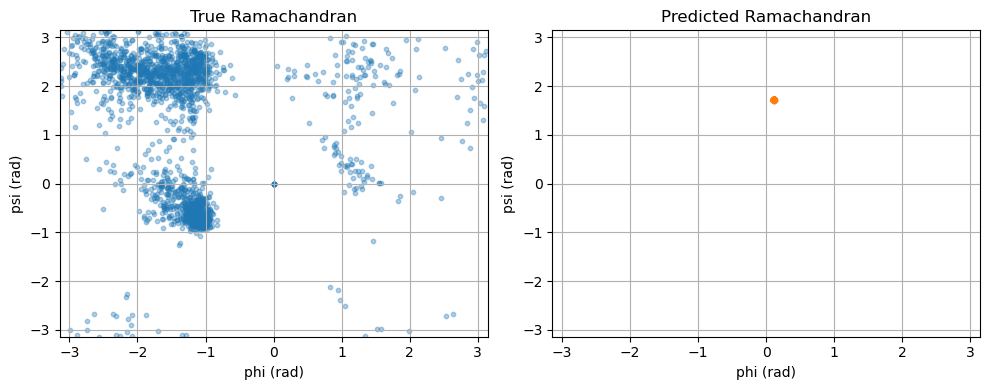

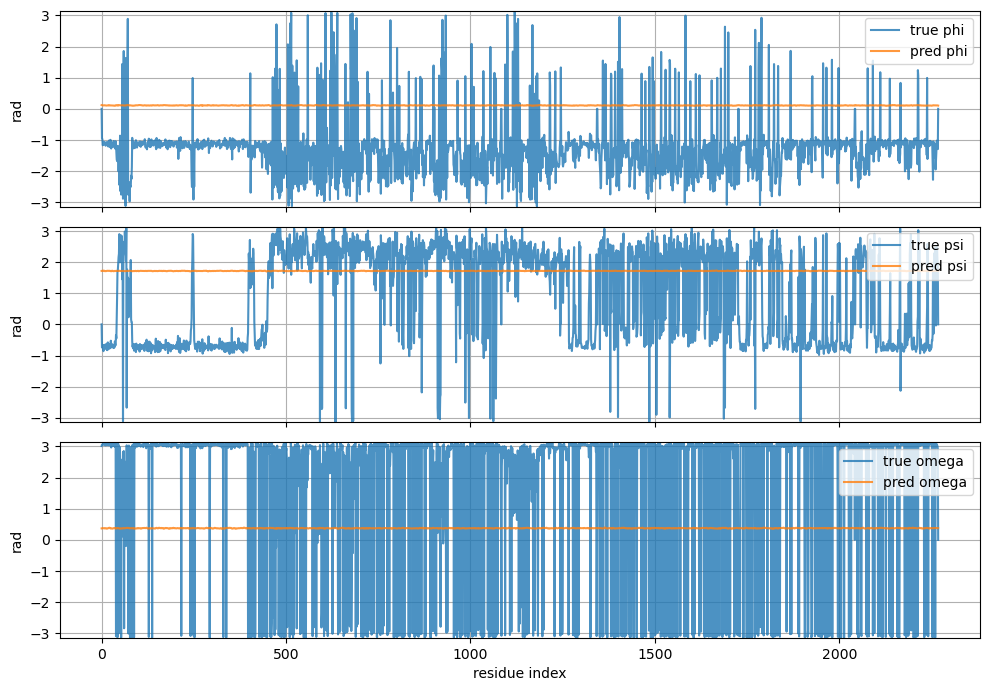

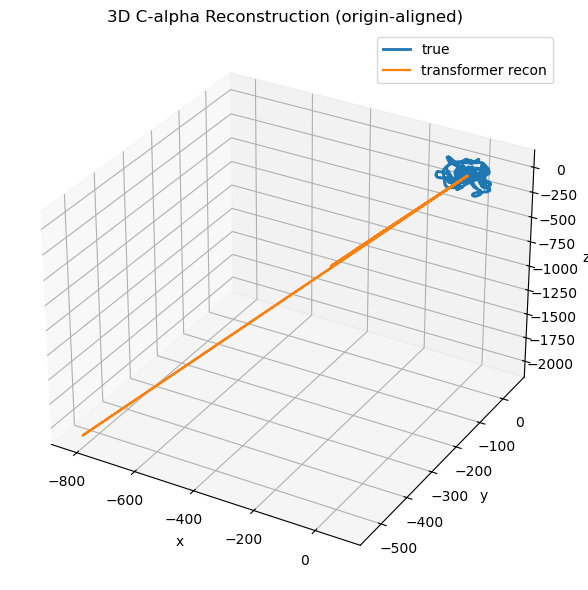

In [11]:
plot_ramachandran(true_angles, pred_angles)
plot_angle_traces(true_angles, pred_angles)
plot_3d_reconstruction(true_coords, pred_coords, se3_coords)


In [12]:
# Debug angle head collapse: inspect shape and per-channel std.
with torch.no_grad():
	dbg = struct_dat[0].to(device)
	dbg = ensure_float32_inplace(dbg)
	dbg = ensure_edge_attrs_inplace(dbg, edge_dim=getattr(encoder, 'edge_dim', 1))
	z_dbg, _ = encoder(dbg)
	dbg['res'].x = z_dbg
	out_dbg = transformer_geom_decoder(dbg, contact_pred_index=None)
	_, _, _, true_ang_dbg, _, _, _ = get_true_geometry(dbg)
	pred_ang_dbg = out_dbg.get('angles')

print('true angles shape:', None if true_ang_dbg is None else tuple(true_ang_dbg.shape))
print('pred angles shape:', None if pred_ang_dbg is None else tuple(pred_ang_dbg.shape))

if pred_ang_dbg is not None:
	pred_norm_dbg = wrap_to_pi_torch(pred_ang_dbg[..., :3])
	print('pred mean:', pred_norm_dbg.mean(dim=0).detach().cpu().numpy())
	print('pred std :', pred_norm_dbg.std(dim=0).detach().cpu().numpy())

if true_ang_dbg is not None:
	true_norm_dbg = maybe_deg_to_rad_torch(true_ang_dbg[..., :3])
	print('true mean:', true_norm_dbg.mean(dim=0).detach().cpu().numpy())
	print('true std :', true_norm_dbg.std(dim=0).detach().cpu().numpy())

true angles shape: (69, 3)
pred angles shape: (69, 3)
pred mean: [0.11100063 1.7151206  0.37222928]
pred std : [0.00472118 0.00453045 0.00731718]
true mean: [-1.1143092  0.8766664  1.6561171]
true std : [0.77966607 1.3642658  2.535535  ]


In [13]:
transformer_geom_decoder.train()
if se3_decoder is not None:
	se3_decoder.train()

trainable_params = list(transformer_geom_decoder.parameters())
if se3_decoder is not None:
	trainable_params += list(se3_decoder.parameters())

optimizer = torch.optim.AdamW(trainable_params, lr=3e-4, weight_decay=1e-4)

n_steps = 3
loss_trace = []
loader_iter = iter(train_loader)
test_steps = False  # Set to False to skip the training loop and just run the sanity forward pass above.

if test_steps == True:
	for step in range(n_steps):
		try:
			data = next(loader_iter).to(device)
		except StopIteration:
			loader_iter = iter(train_loader)
			data = next(loader_iter).to(device)

		data = ensure_float32_inplace(data)
		data = ensure_edge_attrs_inplace(data, edge_dim=getattr(encoder, 'edge_dim', 1))

		with torch.no_grad():
			z, _ = encoder(data)
		data['res'].x = z

		out_t = transformer_geom_decoder(data, contact_pred_index=None)
		true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt = get_true_geometry(data)

		pred_rt = out_t['rt_pred']
		pred_q = pred_rt[..., :4]
		pred_t = pred_rt[..., 4:]
		pred_R = quaternion_to_rotation_matrix(pred_q)

		losses = []

		if true_q is not None and true_t is not None:
			losses.append(0.50 * quaternion_fape_loss(true_q, true_t, pred_q, pred_t, batch=batch_idx))
			losses.append(0.25 * quaternion_geodesic_loss(pred_q, true_q))

		if true_R is not None and true_t is not None:
			losses.append(0.25 * rt_fape_loss(true_R, true_t, pred_R, pred_t, batch=batch_idx))

		pred_coords = reconstruct_positions(
			pred_R, pred_t, batch_idx=batch_idx, translation_frame='global', include_origin=False
		)
		if true_coords is not None:
			losses.append(0.20 * delta_coord_loss(true_coords, pred_coords, plddt=plddt))

		if out_t.get('angles') is not None and true_angles is not None:
			losses.append(0.20 * periodic_angle_smooth_l1(out_t['angles'], true_angles))

		if se3_decoder is not None:
			try:
				data_se3 = data.clone().to(se3_device)
				data_se3 = ensure_float32_inplace(data_se3)
				out_s = se3_decoder(data_se3)

				if out_s.get('coors_out') is not None and true_coords is not None:
					c = out_s['coors_out']
					if c.ndim == 3 and batch_idx is not None:
						coords_split = []
						ub = torch.unique(batch_idx)
						for i, b in enumerate(ub):
							n = int((batch_idx == b).sum().item())
							coords_split.append(c[i, :n])
						se3_coords_step = torch.cat(coords_split, dim=0)
					elif c.ndim == 3:
						se3_coords_step = c[0]
					else:
						se3_coords_step = c
					se3_coords_step = se3_coords_step.to(true_coords.device, dtype=true_coords.dtype)
					losses.append(0.20 * F.mse_loss(se3_coords_step, true_coords))

				if out_s.get('angles') is not None and true_angles is not None:
					losses.append(0.10 * periodic_angle_smooth_l1(out_s['angles'][..., :3], true_angles))
			except Exception as exc:
				print(f'SE3 training branch skipped at step {step} due runtime error: {exc}')

		if len(losses) == 0:
			raise RuntimeError('No valid losses were constructed for this batch.')

		total_loss = torch.stack([l.float() for l in losses]).sum()

		optimizer.zero_grad(set_to_none=True)
		total_loss.backward()
		torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
		optimizer.step()

		loss_trace.append(float(total_loss.detach().cpu()))
		print(f'step={step:02d} total_loss={loss_trace[-1]:.6f}')

	print('loss_trace:', loss_trace)

In [14]:
# Extra training probe: run a few more batches and summarize behavior.
probe_steps = 12
probe_losses = []
probe_se3_skips = 0

transformer_geom_decoder.train()
if se3_decoder is not None:
	se3_decoder.train()

probe_params = list(transformer_geom_decoder.parameters())
if se3_decoder is not None:
	probe_params += list(se3_decoder.parameters())

probe_optimizer = torch.optim.AdamW(probe_params, lr=3e-4, weight_decay=1e-4)
probe_iter = iter(train_loader)

for step in range(probe_steps):
	try:
		data = next(probe_iter).to(device)
	except StopIteration:
		probe_iter = iter(train_loader)
		data = next(probe_iter).to(device)

	data = ensure_float32_inplace(data)
	data = ensure_edge_attrs_inplace(data, edge_dim=getattr(encoder, 'edge_dim', 1))

	with torch.no_grad():
		z, _ = encoder(data)
	data['res'].x = z

	out_t = transformer_geom_decoder(data, contact_pred_index=None)
	true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt = get_true_geometry(data)

	pred_rt = out_t['rt_pred']
	pred_q = pred_rt[..., :4]
	pred_t = pred_rt[..., 4:]
	pred_R = quaternion_to_rotation_matrix(pred_q)

	losses = []

	if true_q is not None and true_t is not None:
		losses.append(0.50 * quaternion_fape_loss(true_q, true_t, pred_q, pred_t, batch=batch_idx))
		losses.append(0.25 * quaternion_geodesic_loss(pred_q, true_q))

	if true_R is not None and true_t is not None:
		losses.append(0.25 * rt_fape_loss(true_R, true_t, pred_R, pred_t, batch=batch_idx))

	pred_coords = reconstruct_positions(
		pred_R, pred_t, batch_idx=batch_idx, translation_frame='global', include_origin=False
	)
	if true_coords is not None:
		losses.append(0.20 * delta_coord_loss(true_coords, pred_coords, plddt=plddt))

	if out_t.get('angles') is not None and true_angles is not None:
		losses.append(0.20 * periodic_angle_smooth_l1(out_t['angles'], true_angles))

	if se3_decoder is not None:
		try:
			data_se3 = data.clone().to(se3_device)
			data_se3 = ensure_float32_inplace(data_se3)
			out_s = se3_decoder(data_se3)

			if out_s.get('coors_out') is not None and true_coords is not None:
				c = out_s['coors_out']
				if c.ndim == 3 and batch_idx is not None:
					coords_split = []
					ub = torch.unique(batch_idx)
					for i, b in enumerate(ub):
						n = int((batch_idx == b).sum().item())
						coords_split.append(c[i, :n])
					se3_coords_step = torch.cat(coords_split, dim=0)
				elif c.ndim == 3:
					se3_coords_step = c[0]
				else:
					se3_coords_step = c
				se3_coords_step = se3_coords_step.to(true_coords.device, dtype=true_coords.dtype)
				losses.append(0.20 * F.mse_loss(se3_coords_step, true_coords))

			if out_s.get('angles') is not None and true_angles is not None:
				losses.append(0.10 * periodic_angle_smooth_l1(out_s['angles'][..., :3], true_angles))
		except Exception as exc:
			probe_se3_skips += 1
			print(f'SE3 branch skipped at probe step {step}: {exc}')

	if len(losses) == 0:
		raise RuntimeError('No valid losses were constructed in probe run.')

	total_loss = torch.stack([l.float() for l in losses]).sum()

	probe_optimizer.zero_grad(set_to_none=True)
	total_loss.backward()
	torch.nn.utils.clip_grad_norm_(probe_params, max_norm=1.0)
	probe_optimizer.step()

	loss_val = float(total_loss.detach().cpu())
	probe_losses.append(loss_val)
	print(f'probe_step={step:02d} total_loss={loss_val:.6f}')

probe_losses_np = np.array(probe_losses, dtype=float)
print('--- probe summary ---')
print('steps:', probe_steps)
print('se3_skips:', probe_se3_skips)
print('first:', float(probe_losses_np[0]))
print('last:', float(probe_losses_np[-1]))
print('min:', float(probe_losses_np.min()))
print('max:', float(probe_losses_np.max()))
print('mean:', float(probe_losses_np.mean()))

SE3 branch skipped at probe step 0: CUDA out of memory. Tried to allocate 3.37 GiB. GPU 1 has a total capacity of 23.42 GiB of which 3.04 GiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB memory in use. Including non-PyTorch memory, this process has 19.92 GiB memory in use. Of the allocated memory 15.06 GiB is allocated by PyTorch, and 4.59 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
probe_step=00 total_loss=5.517714
probe_step=01 total_loss=40.756710
probe_step=02 total_loss=76.080353
SE3 branch skipped at probe step 3: CUDA out of memory. Tried to allocate 2.48 GiB. GPU 1 has a total capacity of 23.42 GiB of which 1.85 GiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB me

In [ ]:
# Full training loop with adjustable epochs and per-epoch recon visualizations.
# Increase these once behavior looks stable.
num_epochs = 1
max_batches_per_epoch = 8  # set to None to use the full train_loader each epoch
viz_sample_idx = 0

# Gradient accumulation controls.
target_effective_batch_size = 10
micro_batch_size = int(getattr(train_loader, 'batch_size', 1) or 1)
accum_steps = max(1, math.ceil(target_effective_batch_size / micro_batch_size))
effective_batch_size = micro_batch_size * accum_steps
print(
	f'micro_batch_size={micro_batch_size} accum_steps={accum_steps} '
	f'effective_batch_size={effective_batch_size}'
)


# Kendall et al. homoscedastic uncertainty weighting.
use_uncertainty_weighting = True
uncertainty_term_names = ['fape_quat', 'quat_geodesic', 'angles' , 'fape_quat_se3', 'quat_geodesic_se3' , 'se3_angles' ]

kendall_log_vars = torch.nn.ParameterDict(
	{name: torch.nn.Parameter(torch.zeros((), device=device, dtype=torch.float32)) for name in uncertainty_term_names}
 )
print('Kendall uncertainty weighting enabled:', use_uncertainty_weighting)

# NaN diagnostics: when enabled, stop immediately and print the exact bad term.
nan_guard = True

def _tstats(name, x):
	if x is None or not isinstance(x, torch.Tensor):
		return f'{name}: None'
	finite = torch.isfinite(x)
	fr = float(finite.float().mean().detach().cpu())
	xf = x[finite]
	if xf.numel() == 0:
		return f'{name}: finite_ratio={fr:.4f} (no finite values)'
	mn = float(xf.min().detach().cpu())
	mx = float(xf.max().detach().cpu())
	return f'{name}: finite_ratio={fr:.4f} min={mn:.6f} max={mx:.6f}'

def _kendall_weight_terms(raw_terms):
	weighted = {}
	for name, loss in raw_terms.items():
		if name not in kendall_log_vars:
			# Fallback for unexpected dynamic keys; keep finite path stable.
			weighted[name] = loss
			continue
		s = kendall_log_vars[name]
		weighted[name] = torch.exp(-s) * loss + s
	return weighted

transformer_geom_decoder.train()
if se3_decoder is not None:
	se3_decoder.train()

train_params = list(transformer_geom_decoder.parameters())
if se3_decoder is not None:
	train_params += list(se3_decoder.parameters())
if use_uncertainty_weighting:
	train_params += list(kendall_log_vars.parameters())

epoch_optimizer = torch.optim.AdamW(train_params, lr=3e-4, weight_decay=1e-4)

epoch_loss_history = []
epoch_se3_skips = []

def _compute_total_loss(data_batch, debug_label=''):
	data_batch = ensure_float32_inplace(data_batch)
	data_batch = ensure_edge_attrs_inplace(data_batch, edge_dim=getattr(encoder, 'edge_dim', 1))

	with torch.no_grad():
		z_local, _ = encoder(data_batch)
	data_batch['res'].x = z_local
	out_local = transformer_geom_decoder(data_batch, contact_pred_index=None)
	true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt = get_true_geometry(data_batch)

	pred_rt = out_local['rt_pred']
	pred_q = pred_rt[..., :4]
	pred_t = pred_rt[..., 4:]
	pred_R = quaternion_to_rotation_matrix(pred_q)

	raw_terms = {}
	if true_q is not None and true_t is not None:
		raw_terms['fape_quat'] = quaternion_fape_loss(true_q, true_t, pred_q, pred_t, batch=batch_idx)
		raw_terms['quat_geodesic'] = quaternion_geodesic_loss(pred_q, true_q)

	pred_coords_local = reconstruct_positions(
		pred_R, pred_t, batch_idx=batch_idx, translation_frame='global', include_origin=False
	)

	# Bridge to SE3 path: provide transformer coordinates as coord_pred.x.
	data_batch['coord_pred'].x = pred_coords_local

	if out_local.get('angles') is not None and true_angles is not None:
		raw_terms['angles'] = periodic_angle_smooth_l1(out_local['angles'], true_angles)

	se3_skip = False
	if se3_decoder is not None:
		try:
			data_se3 = data_batch
			data_se3 = ensure_float32_inplace(data_se3)
			data_se3 = ensure_edge_attrs_inplace(data_se3, edge_dim=getattr(encoder, 'edge_dim', 1))
			out_s = se3_decoder(data_se3)

			if out_s.get('coors_out') is not None and true_coords is not None:
				c = out_s['coors_out']
				if c.ndim == 3 and batch_idx is not None:
					coords_split = []
					ub = torch.unique(batch_idx)
					for i, b in enumerate(ub):
						n = int((batch_idx == b).sum().item())
						coords_split.append(c[i, :n])
					se3_coords_step = torch.cat(coords_split, dim=0)
				elif c.ndim == 3:
					se3_coords_step = c[0]
				else:
					se3_coords_step = c
				se3_coords_step = se3_coords_step.to(true_coords.device, dtype=true_coords.dtype)
				#compute the frames for each batch and concatenate them to get the final se3_coords_step
				rs,ts, qs = [], [], []
				for b in torch.unique(batch_idx):
					mask = (batch_idx == b)
					if se3_coords_b.shape[0] == 0:
						continue
					se3_coords_b = se3_coords_step[mask]
					r,t,q = pdb_to_graph.compute_local_frame(se3_coords_b)
					rs.append(r)
					ts.append(t)
					qs.append(q)
				qs = torch.cat(qs, dim=0)
				ts = torch.cat(ts, dim=0)
				rs = torch.cat(rs, dim=0)
				raw_terms['fape_quat_se3'] = quaternion_fape_loss(true_q, true_t, qs, ts, batch=batch_idx)
				raw_terms['quat_geodesic_se3'] = quaternion_geodesic_loss(qs, true_q)

			if out_s.get('angles') is not None and true_angles is not None:
				raw_terms['se3_angles'] = periodic_angle_smooth_l1(out_s['angles'][..., :3], true_angles)
		except Exception as exc:
			se3_skip = True
			print(f'SE3 branch skipped in epoch loop due runtime error: {exc}')

	if len(raw_terms) == 0:
		raise RuntimeError('No valid losses were constructed in epoch loop.')

	if nan_guard:
		bad_terms = [k for k, v in raw_terms.items() if not torch.isfinite(v).all()]
		if bad_terms:
			print(f'Non-finite raw loss terms at {debug_label}: {bad_terms}')
			for name in bad_terms:
				print(f'  {name}: {raw_terms[name]}')
			print(_tstats('true_angles', true_angles))
			print(_tstats('pred_angles', out_local.get('angles')))
			print(_tstats('true_coords', true_coords))
			print(_tstats('pred_coords', pred_coords_local))
			print(_tstats('true_q', true_q))
			print(_tstats('pred_q', pred_q))
			raise RuntimeError(f'Non-finite raw loss term(s) at {debug_label}: {bad_terms}')

	weighted_terms = _kendall_weight_terms(raw_terms) if use_uncertainty_weighting else raw_terms
	total = torch.stack([v.float() for v in weighted_terms.values()]).sum()

	if nan_guard and (not torch.isfinite(total).all()):
		print(f'Non-finite total loss at {debug_label}')
		print('raw term values:', {k: float(v.detach().cpu()) if torch.isfinite(v).all() else str(v) for k, v in raw_terms.items()})
		if use_uncertainty_weighting:
			print('kendall sigmas:', {k: float(torch.exp(0.5 * kendall_log_vars[k]).detach().cpu()) for k in raw_terms if k in kendall_log_vars})
		print(_tstats('true_angles', true_angles))
		print(_tstats('pred_angles', out_local.get('angles')))
		print(_tstats('true_coords', true_coords))
		print(_tstats('pred_coords', pred_coords_local))
		raise RuntimeError(f'Non-finite total loss at {debug_label}')

	return total, out_local, pred_coords_local, true_angles, true_coords, se3_skip



micro_batch_size=5 accum_steps=2 effective_batch_size=10
Kendall uncertainty weighting enabled: True


epoch 1/1:   0%|          | 0/8 [00:00<?, ?it/s]

SE3 branch skipped in epoch loop due runtime error: CUDA out of memory. Tried to allocate 1.99 GiB. GPU 1 has a total capacity of 23.42 GiB of which 636.31 MiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB memory in use. Including non-PyTorch memory, this process has 22.33 GiB memory in use. Of the allocated memory 19.44 GiB is allocated by PyTorch, and 2.62 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
SE3 branch skipped in epoch loop due runtime error: CUDA out of memory. Tried to allocate 2.29 GiB. GPU 1 has a total capacity of 23.42 GiB of which 244.31 MiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB memory in use. Including non-PyTorch memory, this process has 22.71 Gi

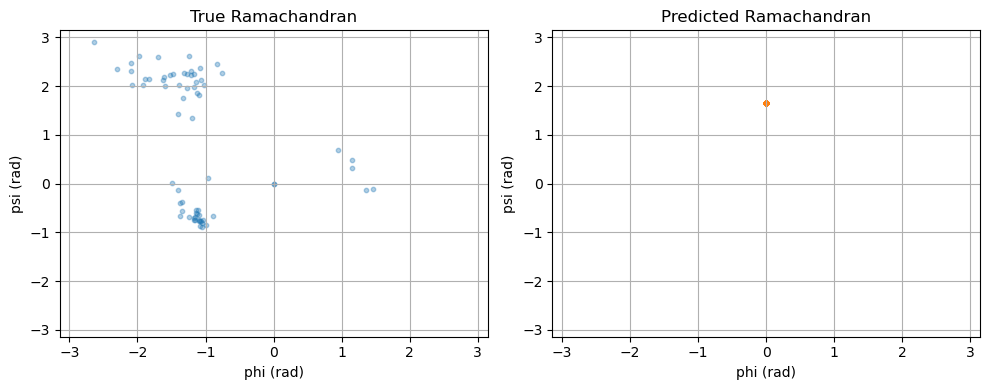

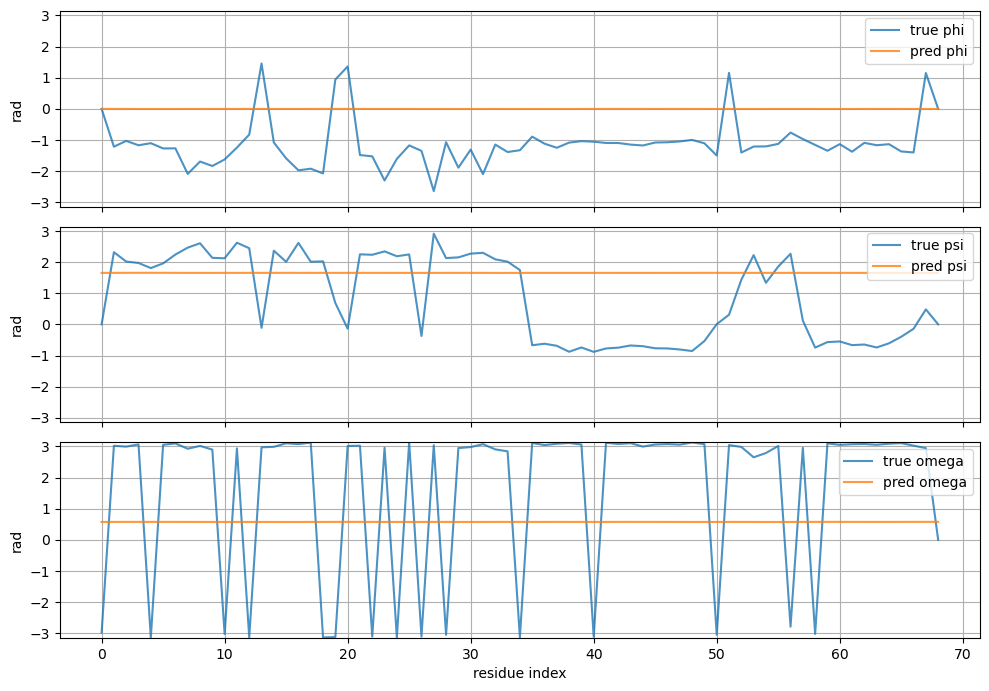

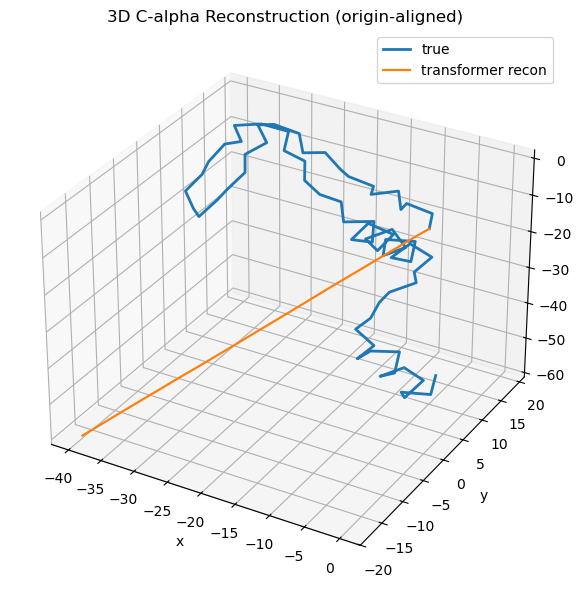

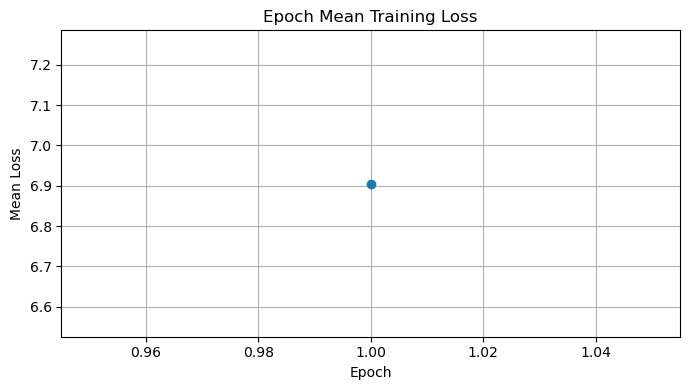

In [16]:

for epoch in range(num_epochs):
	running_losses = []
	se3_skip_count = 0

	iter_loader = iter(train_loader)
	step = 0
	epoch_optimizer.zero_grad(set_to_none=True)

	target_steps = max_batches_per_epoch if max_batches_per_epoch is not None else len(train_loader)
	pbar = tqdm(total=target_steps, desc=f'epoch {epoch+1}/{num_epochs}', leave=False)

	while True:
		if max_batches_per_epoch is not None and step >= max_batches_per_epoch:
			break

		try:
			batch = next(iter_loader).to(device)
		except StopIteration:
			break

		total_loss, _, _, _, _, se3_skip = _compute_total_loss(batch, debug_label=f'epoch={epoch+1} step={step}')
		if se3_skip:
			se3_skip_count += 1

		(total_loss / accum_steps).backward()

		should_step = ((step + 1) % accum_steps == 0)
		if should_step:
			torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
			epoch_optimizer.step()
			epoch_optimizer.zero_grad(set_to_none=True)

		running_losses.append(float(total_loss.detach().cpu()))
		step += 1
		pbar.update(1)
		pbar.set_postfix(loss=f'{running_losses[-1]:.4f}', se3_skips=se3_skip_count)

	# Flush remaining gradients if epoch ended mid-accumulation.
	if step > 0 and (step % accum_steps != 0):
		torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
		epoch_optimizer.step()
		epoch_optimizer.zero_grad(set_to_none=True)

	pbar.close()

	if len(running_losses) == 0:
		raise RuntimeError('Epoch loop got zero batches; check loader and max_batches_per_epoch.')

	epoch_mean = float(np.mean(running_losses))
	epoch_loss_history.append(epoch_mean)
	epoch_se3_skips.append(se3_skip_count)

	print(
		f'epoch={epoch+1}/{num_epochs} batches={len(running_losses)} mean_loss={epoch_mean:.6f} '
		f'se3_skips={se3_skip_count} accum_steps={accum_steps}'
	)
	if use_uncertainty_weighting:
		print('kendall sigmas:', {k: float(torch.exp(0.5 * v).detach().cpu()) for k, v in kendall_log_vars.items()})

	# Per-epoch reconstruction visualization on a fixed sample for comparability.
	transformer_geom_decoder.eval()
	with torch.no_grad():
		viz_sample = struct_dat[viz_sample_idx].to(device)
		viz_sample = ensure_float32_inplace(viz_sample)
		viz_sample = ensure_edge_attrs_inplace(viz_sample, edge_dim=getattr(encoder, 'edge_dim', 1))

		z_viz, _ = encoder(viz_sample)
		viz_sample['res'].x = z_viz

		out_viz = transformer_geom_decoder(viz_sample, contact_pred_index=None)
		_, _, _, viz_true_angles, viz_true_coords, viz_batch_idx, _ = get_true_geometry(viz_sample)
		viz_pred_rt = out_viz['rt_pred']
		viz_pred_q = viz_pred_rt[..., :4]
		viz_pred_t = viz_pred_rt[..., 4:]
		viz_pred_R = quaternion_to_rotation_matrix(viz_pred_q)
		viz_pred_coords = reconstruct_positions(
			viz_pred_R, viz_pred_t, batch_idx=viz_batch_idx, translation_frame='global', include_origin=False
		)
		viz_pred_angles = out_viz.get('angles')

	print(f'epoch {epoch+1}: reconstruction snapshots')
	plot_ramachandran(viz_true_angles, viz_pred_angles)
	plot_angle_traces(viz_true_angles, viz_pred_angles)
	plot_3d_reconstruction(viz_true_coords, viz_pred_coords, None)

	transformer_geom_decoder.train()

# Plot epoch-level trend.
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(epoch_loss_history) + 1), epoch_loss_history, marker='o')
plt.title('Epoch Mean Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Loss')
plt.grid(True)
plt.tight_layout()

print('epoch_loss_history:', epoch_loss_history)
print('epoch_se3_skips:', epoch_se3_skips)

In [17]:
# NaN tracer: isolate first non-finite loss term/tensor in training.

nan_probe_steps = 512
run_se3_in_probe = False  # set True if you want to include SE3 terms in this diagnostic

def finite_ratio(x):
	if x is None or not isinstance(x, torch.Tensor):
		return None
	return float(torch.isfinite(x).float().mean().detach().cpu())

def tensor_stats(x):
	if x is None or not isinstance(x, torch.Tensor):
		return {'finite_ratio': None, 'min': None, 'max': None}
	xf = x[torch.isfinite(x)]
	if xf.numel() == 0:
		return {'finite_ratio': 0.0, 'min': None, 'max': None}
	return {
		'finite_ratio': float(torch.isfinite(x).float().mean().detach().cpu()),
		'min': float(xf.min().detach().cpu()),
		'max': float(xf.max().detach().cpu()),
	}

transformer_geom_decoder.train()
if se3_decoder is not None:
	se3_decoder.train()

nan_probe_params = list(transformer_geom_decoder.parameters())
if run_se3_in_probe and se3_decoder is not None:
	nan_probe_params += list(se3_decoder.parameters())

nan_probe_opt = torch.optim.AdamW(nan_probe_params, lr=3e-4, weight_decay=1e-4)
nan_probe_iter = iter(train_loader)

found_issue = False
issue_step = None
issue_msg = None

for step in range(nan_probe_steps):
	try:
		data = next(nan_probe_iter).to(device)
	except StopIteration:
		nan_probe_iter = iter(train_loader)
		data = next(nan_probe_iter).to(device)

	data = ensure_float32_inplace(data)
	data = ensure_edge_attrs_inplace(data, edge_dim=getattr(encoder, 'edge_dim', 1))

	with torch.no_grad():
		z, _ = encoder(data)
	data['res'].x = z

	out_t = transformer_geom_decoder(data, contact_pred_index=None)
	true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt = get_true_geometry(data)

	pred_rt = out_t['rt_pred']
	pred_q = pred_rt[..., :4]
	pred_t = pred_rt[..., 4:]
	pred_R = quaternion_to_rotation_matrix(pred_q)

	term_map = {}
	aux_stats = {
		'true_q': tensor_stats(true_q),
		'true_t': tensor_stats(true_t),
		'true_R': tensor_stats(true_R),
		'true_angles': tensor_stats(true_angles),
		'true_coords': tensor_stats(true_coords),
		'plddt': tensor_stats(plddt),
		'pred_q': tensor_stats(pred_q),
		'pred_t': tensor_stats(pred_t),
		'pred_R': tensor_stats(pred_R),
	}

	if true_q is not None and true_t is not None:
		term_map['fape_quat'] = 0.50 * quaternion_fape_loss(true_q, true_t, pred_q, pred_t, batch=batch_idx)
		term_map['quat_geodesic'] = 0.25 * quaternion_geodesic_loss(pred_q, true_q)

	if true_R is not None and true_t is not None:
		term_map['fape_rt'] = 0.25 * rt_fape_loss(true_R, true_t, pred_R, pred_t, batch=batch_idx)

	pred_coords = reconstruct_positions(
		pred_R, pred_t, batch_idx=batch_idx, translation_frame='global', include_origin=False
	)
	aux_stats['pred_coords'] = tensor_stats(pred_coords)

	if true_coords is not None:
		term_map['delta_coords'] = 0.20 * delta_coord_loss(true_coords, pred_coords, plddt=plddt)

	if out_t.get('angles') is not None and true_angles is not None:
		aux_stats['pred_angles'] = tensor_stats(out_t['angles'])
		term_map['angles'] = 0.20 * periodic_angle_smooth_l1(out_t['angles'], true_angles)

	if run_se3_in_probe and se3_decoder is not None:
		try:
			data_se3 = data.clone().to(se3_device)
			data_se3 = ensure_float32_inplace(data_se3)
			out_s = se3_decoder(data_se3)

			if out_s.get('pred_coords') is not None and true_coords is not None:
				c = out_s['pred_coords']
				if c.ndim == 3 and batch_idx is not None:
					coords_split = []
					ub = torch.unique(batch_idx)
					for i, b in enumerate(ub):
						n = int((batch_idx == b).sum().item())
						coords_split.append(c[i, :n])
					se3_coords_step = torch.cat(coords_split, dim=0)
				elif c.ndim == 3:
					se3_coords_step = c[0]
				else:
					se3_coords_step = c
				se3_coords_step = se3_coords_step.to(true_coords.device, dtype=true_coords.dtype)
				aux_stats['se3_coords'] = tensor_stats(se3_coords_step)
				#term_map['se3_coords'] = 0.20 * F.mse_loss(se3_coords_step, true_coords)
				#get frames and compute fape
				
			if out_s.get('angles') is not None and true_angles is not None:
				aux_stats['se3_angles'] = tensor_stats(out_s['angles'])
				term_map['se3_angles'] = 0.10 * periodic_angle_smooth_l1(out_s['angles'][..., :3], true_angles)
		except Exception as exc:
			issue_step = step
			issue_msg = f'SE3 runtime exception at step {step}: {exc}'
			found_issue = True
			break

	if len(term_map) == 0:
		issue_step = step
		issue_msg = f'No terms built at step {step}'
		found_issue = True
		break

	bad_terms = [k for k, v in term_map.items() if not torch.isfinite(v).all()]
	if bad_terms:
		issue_step = step
		issue_msg = f'Non-finite term(s) at step {step}: {bad_terms}'
		found_issue = True
		print(issue_msg)
		for name in bad_terms:
			v = term_map[name]
			print(f'  {name}: {v}')
		print('aux tensor stats:')
		for k, st in aux_stats.items():
			print(f'  {k}: {st}')
		break

	total_loss = torch.stack([v.float() for v in term_map.values()]).sum()
	if not torch.isfinite(total_loss).all():
		issue_step = step
		issue_msg = f'Total loss non-finite at step {step}'
		found_issue = True
		print(issue_msg)
		print('term values:', {k: float(v.detach().cpu()) for k, v in term_map.items()})
		print('aux tensor stats:')
		for k, st in aux_stats.items():
			print(f'  {k}: {st}')
		break

	nan_probe_opt.zero_grad(set_to_none=True)
	total_loss.backward()

	# Check gradients before optimizer step.
	grad_bad = []
	for p in nan_probe_params:
		if p.grad is not None and not torch.isfinite(p.grad).all():
			grad_bad.append(tuple(p.shape))
	if grad_bad:
		issue_step = step
		issue_msg = f'Non-finite gradients at step {step}; bad grad param shapes: {grad_bad[:8]}'
		found_issue = True
		print(issue_msg)
		print('term values:', {k: float(v.detach().cpu()) for k, v in term_map.items()})
		break

	torch.nn.utils.clip_grad_norm_(nan_probe_params, max_norm=1.0)
	nan_probe_opt.step()

	if step % 50 == 0:
		print(f'nan_probe step {step}: total_loss={float(total_loss.detach().cpu()):.6f}')

if not found_issue:
	print(f'No non-finite values found in first {nan_probe_steps} steps (run_se3_in_probe={run_se3_in_probe}).')
else:
	print('first_issue_step:', issue_step)
	print('first_issue:', issue_msg)

nan_probe step 0: total_loss=5.203450
nan_probe step 50: total_loss=4.912057
nan_probe step 100: total_loss=4.806176
nan_probe step 150: total_loss=4.757923
nan_probe step 200: total_loss=4.700586
nan_probe step 250: total_loss=4.444491
nan_probe step 300: total_loss=4.478918
nan_probe step 350: total_loss=4.475554
nan_probe step 400: total_loss=4.478598
nan_probe step 450: total_loss=4.440274
nan_probe step 500: total_loss=4.398438


KeyboardInterrupt: 

In [ ]:
# SE3-on NaN probe using guarded _compute_total_loss.
se3_nan_probe_steps = 256
se3_nan_probe_skips = 0

if se3_decoder is None:
	print('SE3 probe skipped: se3_decoder is None')
else:
	transformer_geom_decoder.train()
	se3_decoder.train()

	probe_iter = iter(train_loader)
	for step in range(se3_nan_probe_steps):
		try:
			batch = next(probe_iter).to(device)
		except StopIteration:
			probe_iter = iter(train_loader)
			batch = next(probe_iter).to(device)

		try:
			total_loss, _, _, _, _, se3_skip = _compute_total_loss(
				batch, debug_label=f'se3_nan_probe step={step}'
			)
			if se3_skip:
				se3_nan_probe_skips += 1
			if step % 50 == 0:
				print(f'se3_nan_probe step {step}: total_loss={float(total_loss.detach().cpu()):.6f} skips={se3_nan_probe_skips}')
		except Exception as exc:
			print(f'SE3 NaN probe stopped at step {step}: {exc}')
			break
	else:
		print(f'SE3 NaN probe completed {se3_nan_probe_steps} steps with no non-finite loss terms.')
		print(f'SE3 runtime skips observed: {se3_nan_probe_skips}')

SE3 branch skipped in epoch loop due runtime error: CUDA out of memory. Tried to allocate 788.00 MiB. GPU 1 has a total capacity of 23.42 GiB of which 390.31 MiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB memory in use. Including non-PyTorch memory, this process has 22.57 GiB memory in use. Of the allocated memory 17.74 GiB is allocated by PyTorch, and 4.56 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
se3_nan_probe step 0: total_loss=5.422074 skips=1
SE3 branch skipped in epoch loop due runtime error: CUDA out of memory. Tried to allocate 5.99 GiB. GPU 1 has a total capacity of 23.42 GiB of which 424.31 MiB is free. Process 265152 has 224.00 MiB memory in use. Process 664615 has 224.00 MiB memory in use. Inc

KeyboardInterrupt: 

In [18]:
#clear cuda cache to free up memory after probes
torch.cuda.empty_cache()

In [19]:
# Quick summary of NaN diagnostics state.
print('found_issue:', found_issue)
print('issue_step:', issue_step)
print('issue_msg:', issue_msg)
print('run_se3_in_probe (tracer cell):', run_se3_in_probe)
print('se3_nan_probe_steps:', se3_nan_probe_steps)
print('se3_nan_probe_skips:', se3_nan_probe_skips)

def count_nonfinite_params(module):
	bad = 0
	total = 0
	for p in module.parameters():
		total += p.numel()
		bad += int((~torch.isfinite(p)).sum().item())
	return bad, total

bad_t, tot_t = count_nonfinite_params(transformer_geom_decoder)
print(f'transformer nonfinite params: {bad_t}/{tot_t}')

if se3_decoder is not None:
	bad_s, tot_s = count_nonfinite_params(se3_decoder)
	print(f'se3 nonfinite params: {bad_s}/{tot_s}')

found_issue: False
issue_step: None
issue_msg: None
run_se3_in_probe (tracer cell): False


NameError: name 'se3_nan_probe_steps' is not defined

In [1]:
# Full-dataset run before qualitative inspection.
import math

long_num_epochs = 20
target_effective_batch_size = 10
use_se3_in_long_run = False  # keep False unless SE3 path is stable at your memory budget
long_viz_sample_idx = 0       # fixed sample index used for per-epoch reconstruction plots

if '_compute_total_loss' not in globals():
	raise RuntimeError('Run the full training-loop setup cell first to define _compute_total_loss.')

micro_batch_size = int(getattr(train_loader, 'batch_size', 1) or 1)
accum_steps = max(1, math.ceil(target_effective_batch_size / micro_batch_size))
effective_batch_size = micro_batch_size * accum_steps
print(
	f'long loop config: micro_batch_size={micro_batch_size} accum_steps={accum_steps} '
	f'effective_batch_size={effective_batch_size}'
)

transformer_geom_decoder.train()
if se3_decoder is not None:
	se3_decoder.train()

long_train_params = list(transformer_geom_decoder.parameters())
if use_se3_in_long_run and se3_decoder is not None:
	long_train_params += list(se3_decoder.parameters())
if ('use_uncertainty_weighting' in globals()) and use_uncertainty_weighting and ('kendall_log_vars' in globals()):
	long_train_params += list(kendall_log_vars.parameters())

long_optimizer = torch.optim.AdamW(long_train_params, lr=1e-4, weight_decay=0.0)

long_epoch_loss_history = []
long_epoch_se3_skips = []
long_epoch_structures = []
long_epoch_steps = []

se3_decoder_backup = se3_decoder
if not use_se3_in_long_run:
	se3_decoder = None

try:
	for epoch in range(long_num_epochs):
		running_losses = []
		se3_skip_count = 0
		structures_seen = 0
		step = 0

		long_optimizer.zero_grad(set_to_none=True)
		pbar = tqdm(train_loader, total=len(train_loader), desc=f'long epoch {epoch+1}/{long_num_epochs}', leave=False)

		total_loss = torch.tensor(0.0, device=device)
		for batch in pbar:
			batch = batch.to(device)

			if ('res' in batch.node_types) and hasattr(batch['res'], 'batch') and (batch['res'].batch is not None):
				structures_in_batch = int(torch.unique(batch['res'].batch).numel())
			else:
				structures_in_batch = micro_batch_size

			loss, _, _, _, _, se3_skip = _compute_total_loss(
				batch, debug_label=f'long_epoch={epoch+1} step={step}'
			)
			if se3_skip:
				se3_skip_count += 1

			total_loss += loss
			running_losses.append(float(loss.detach().cpu()))

			should_step = ((step + 1) % accum_steps == 0)
			if should_step:
				(total_loss / accum_steps).backward()
				torch.nn.utils.clip_grad_norm_(long_train_params, max_norm=1.0)
				long_optimizer.step()
				long_optimizer.zero_grad(set_to_none=True)
				total_loss = torch.tensor(0.0, device=device)
			structures_seen += structures_in_batch
			step += 1
			pbar.set_postfix(loss=f'{np.mean(running_losses[-10:]):.4f}', se3_skips=se3_skip_count)

		# Flush remaining gradients if epoch ended mid-accumulation.
		if step > 0 and (step % accum_steps != 0):
			(total_loss / max(1, step % accum_steps)).backward()
			torch.nn.utils.clip_grad_norm_(long_train_params, max_norm=1.0)
			long_optimizer.step()
			long_optimizer.zero_grad(set_to_none=True)
			#clear cuda cache to prevent potential OOM in next epoch if we had a large final micro-batch
			torch.cuda.empty_cache()

		pbar.close()

		if len(running_losses) == 0:
			raise RuntimeError('Long run got zero batches; check loader configuration.')

		epoch_mean = float(np.mean(running_losses))
		long_epoch_loss_history.append(epoch_mean)
		long_epoch_se3_skips.append(se3_skip_count)
		long_epoch_structures.append(structures_seen)
		long_epoch_steps.append(step)
		print(
			f'long_epoch={epoch+1}/{long_num_epochs} steps={step} structures={structures_seen} '
			f'mean_loss={epoch_mean:.6f} se3_skips={se3_skip_count} accum_steps={accum_steps}'
		)
		if ('use_uncertainty_weighting' in globals()) and use_uncertainty_weighting and ('kendall_log_vars' in globals()):
			print('kendall sigmas:', {k: float(torch.exp(0.5 * v).detach().cpu()) for k, v in kendall_log_vars.items()})
		#print the different losses if they are available in the current epoch
		
		# Per-epoch reconstruction snapshot on a fixed sample.
		transformer_geom_decoder.eval()
		with torch.no_grad():
			long_viz_sample = struct_dat[long_viz_sample_idx].to(device)
			long_viz_sample = ensure_float32_inplace(long_viz_sample)
			long_viz_sample = ensure_edge_attrs_inplace(long_viz_sample, edge_dim=getattr(encoder, 'edge_dim', 1))

			z_long_viz, _ = encoder(long_viz_sample)
			long_viz_sample['res'].x = z_long_viz

			out_long_viz = transformer_geom_decoder(long_viz_sample, contact_pred_index=None)
			_, _, _, _, long_viz_true_coords, long_viz_batch_idx, _ = get_true_geometry(long_viz_sample)
			long_viz_pred_rt = out_long_viz['rt_pred']
			long_viz_pred_q = long_viz_pred_rt[..., :4]
			long_viz_pred_t = long_viz_pred_rt[..., 4:]
			long_viz_pred_R = quaternion_to_rotation_matrix(long_viz_pred_q)
			long_viz_pred_coords = reconstruct_positions(
				long_viz_pred_R,
				long_viz_pred_t,
				batch_idx=long_viz_batch_idx,
				translation_frame='global',
				include_origin=False,
			)

		print(f'long epoch {epoch+1}: reconstruction snapshot')
		plot_3d_reconstruction(long_viz_true_coords, long_viz_pred_coords, None)

		transformer_geom_decoder.train()
		if se3_decoder is not None:
			se3_decoder.train()
finally:
	se3_decoder = se3_decoder_backup

print('use_se3_in_long_run:', use_se3_in_long_run)
print('long_epoch_loss_history:', long_epoch_loss_history)
print('long_epoch_se3_skips:', long_epoch_se3_skips)
print('long_epoch_structures:', long_epoch_structures)
print('long_epoch_steps:', long_epoch_steps)

RuntimeError: Run the full training-loop setup cell first to define _compute_total_loss.

In [ ]:
# FAPE sanity test from raw structure input (pdbgraphmk2), including CA-noise sweep.
import pandas as pd

# Reuse notebook seed if available for reproducibility.
_rng_seed = int(SEED) if 'SEED' in globals() else 42

# User-requested example structure.
preferred_structure = Path('/home/dmoi/projects/foldtree2/foldtree2/config/1eei.pdb')

# Keep fallbacks so the cell is still robust if files move.
_repo = Path(repo_root) if 'repo_root' in globals() else Path('/home/dmoi/projects/foldtree2')
_structure_candidates = [
	preferred_structure,
	_repo / 'tmp' / 'A0CST5.pdb',
	_repo / 'tmp' / 'A0A0C2GTF1.pdb',
]
structure_path = next((p for p in _structure_candidates if p.exists()), None)
if structure_path is None:
	raise FileNotFoundError('No test structure found. Update preferred_structure or _structure_candidates.')

# Build structure features with pdbgraphmk2 (source of truth for this test).
p2g = pdbgraphmk2.PDB2PyG()
feat = p2g.create_features(str(structure_path))
if feat is None:
	raise RuntimeError(f'Failed to parse structure: {structure_path}')

# Backbone tensors used by pdbgraphmk2 frame builder.
ca = torch.tensor(feat['coords'], dtype=torch.float32)
n = torch.tensor(feat['ncoords'], dtype=torch.float32)
c = torch.tensor(feat['ccoords'], dtype=torch.float32)
residue_frames = torch.stack([n, ca, c], dim=1)

# Convert to frame representations (R, t, q) using pdbgraphmk2 implementation.
R_true, t_true, q_true = p2g.compute_local_frame(residue_frames)

# Single-structure batch index expected by rt_fape_loss in foldtree2.src.losses.fape.
batch_idx_local = torch.zeros(ca.shape[0], dtype=torch.long)

# Self-vs-self baselines should be ~0.
fape_rt_self = float(rt_fape_loss(R_true, t_true, R_true, t_true, batch=batch_idx_local).detach().cpu())
fape_quat_self = float(quaternion_fape_loss(q_true, t_true, q_true, t_true, batch=batch_idx_local).detach().cpu())

noise_stds = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
rows = []

for sigma in noise_stds:
	g = torch.Generator().manual_seed(_rng_seed)
	noisy_ca = ca if sigma == 0.0 else (ca + sigma * torch.randn(ca.shape, generator=g, dtype=ca.dtype))

	noisy_frames = torch.stack([n, noisy_ca, c], dim=1)
	R_noisy, t_noisy, q_noisy = p2g.compute_local_frame(noisy_frames)

	fape_rt = float(rt_fape_loss(R_true, t_true, R_noisy, t_noisy, batch=batch_idx_local).detach().cpu())
	fape_quat = float(quaternion_fape_loss(q_true, t_true, q_noisy, t_noisy, batch=batch_idx_local).detach().cpu())

	rows.append({
		'noise_std_A': sigma,
		'fape_rt': fape_rt,
		'fape_quat': fape_quat,
		'rt_over_self': fape_rt / max(fape_rt_self, 1e-12),
		'quat_over_self': fape_quat / max(fape_quat_self, 1e-12),
	})

fape_noise_df = pd.DataFrame(rows)

print(f'structure_path: {structure_path}')
print(f'n_residues: {ca.shape[0]}')
print(f'fape_rt_self   : {fape_rt_self:.10f}')
print(f'fape_quat_self : {fape_quat_self:.10f}')
display(fape_noise_df)

# User requested one main metric in the end: keep quat as the primary readout.
PRIMARY_FAPE_METRIC = 'fape_quat'
print('primary_metric_for_followup =', PRIMARY_FAPE_METRIC)

structure_path: /home/dmoi/projects/foldtree2/foldtree2/config/1eei.pdb
n_residues: 103
fape_rt_self   : 0.0001000000
fape_quat_self : 0.0001000000


,noise_std_A,fape_rt,fape_quat,rt_over_self,quat_over_self
0,0.00,0.000100,0.000100,1.000000,1.000000
1,0.01,0.051228,0.051228,512.280254,512.280291
2,0.05,0.256021,0.256021,2560.209436,2560.209734
3,0.10,0.511826,0.511826,5118.259395,5118.259395
4,0.20,1.022188,1.022188,10221.884651,10221.884651
5,0.50,2.575921,2.575922,25759.222993,25759.227761
6,1.00,4.458994,4.458994,44589.961234,44589.961234
7,2.00,6.892462,6.892462,68924.644583,68924.649352


primary_metric_for_followup = fape_quat


## Notes
- If you have a pretrained encoder checkpoint, set `PRETRAINED_ENCODER_PATH` and rerun.
- The smoke loop is intentionally short and diagnostics-first.
- Extend with longer runs only after losses are finite and reconstructions are visually sensible.
